# Introduction to NumPy

Goal: Learn about effectively loading, storing and manipulating in-memory data in Python

# Thinking about datasets

- Wide range of sources
- Wide range of formats
    - Collections of documents
    - Collections of images
    - Collections of sounds clips
    - Collections of numerical measurements
    - etc.

- Seemingly heterogeneous
- Useful to think of all data fundamentally as __arrays of numbers__.

# Example: Digital Images

Simply two-dimensional arrays of numbers representing pixel brightness across the area.


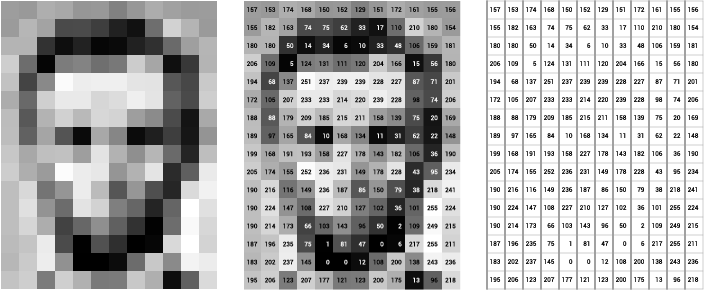
(image from https://ai.stanford.edu/~syyeung/cvweb/Pictures1/imagematrix.png)

In [1]:
from skimage import io

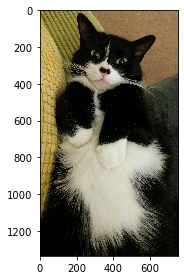

In [2]:
im = io.imread("bert.jpg")
io.imshow(im)
io.show()

In [ ]:
im = io.imread("Charlie.jpeg")
io.imshow(im)
io.show()

In [3]:
im

array([[[140, 133,  42],
        [133, 126,  35],
        [139, 132,  41],
        ...,
        [158, 125,  94],
        [160, 128,  90],
        [155, 124,  78]],

       [[136, 128,  30],
        [137, 128,  33],
        [146, 137,  46],
        ...,
        [156, 122,  95],
        [160, 125,  97],
        [158, 123,  91]],

       [[135, 127,  29],
        [139, 130,  39],
        [146, 136,  51],
        ...,
        [157, 121,  97],
        [162, 125, 106],
        [163, 127, 105]],

       ...,

       [[  0,   2,   1],
        [  0,   2,   1],
        [  0,   2,   1],
        ...,
        [  9,   9,  17],
        [  5,   8,  15],
        [  3,   6,  15]],

       [[  0,   2,   1],
        [  0,   2,   1],
        [  0,   2,   1],
        ...,
        [  9,   9,  19],
        [  5,   7,  19],
        [  3,   5,  17]],

       [[  0,   2,   1],
        [  0,   2,   1],
        [  0,   2,   1],
        ...,
        [  6,   9,  18],
        [  7,   9,  21],
        [  3,   5,  18]]

# Example: Sound Clips

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile

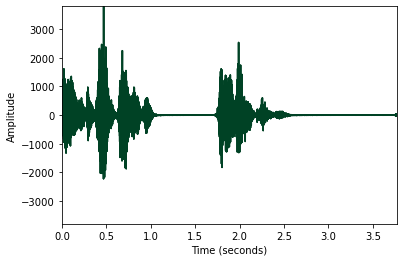

In [5]:
'''code from: https://medium.com/swlh/visualising-speech-74137f0b793b'''
wavfn= "intro.wav"
fs, x = wavfile.read(wavfn)
y = np.linspace(0,len(x)/float(fs), len(x))
ya = np.max(np.absolute(x))
plt.plot(y, x, color="#004225")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.ylim(-ya, ya)
plt.xlim(0, y[-1])
plt.show()

In [6]:
x

array([[-20, -20],
       [ 48,  47],
       [ 86,  88],
       ...,
       [-34, -28],
       [-28, -33],
       [-35, -30]], dtype=int16)

# Numerical Arrays

- Efficient storage and manipulation is fundamental to the data science process

# NumPy

- Ensure it is installed:

    - `conda install numpy`

- Whenever you want to use the package, ensure the following is imported at the start of your workbooks:

    - `import numpy as np`

# Data Types in Python

- Python is easy to use, primarily because of __dynamic typing__
- Java or C requires variables to be explicitly declared with a type e.g *int*
    - e.g in Java `int x = 10`
- Python skips this step
    - e.g `x = 10`
- What this means is that types are dynamically inferred, so changing what is stored is simple:
    `x = "ten"`
- This wouldn't work in Java or C.

# Why does this work?

- Python is written in C
- Every Python object is a cleverly disguised C-structure
- When declaring an integer, it is not just a raw integer, but a pointer to a structure containing lots of information e.g type, size, digit and reference count.
- Given this, there is some overhead computationally and comes at a cost which is apparent in structures that combine these objects

# Python Lists

- The standard mutable multi-element container in Python is a list.

In [10]:
L = list(range(10))
print(L)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [11]:
type(L[0])

int

In [12]:
L2 = [str(c) for c in L]
L2

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [13]:
type(L2[0])

str

In [14]:
L3 = [True, "2", 3.0, 4]
[type(item) for item in L3]

[bool, str, float, int]

- This comes at a cost with the overhead of all the different item types in a list.
- If all variables are of the same type, much of the information held in the structures is redundant.
- Much more efficient to store in a fixed-type array.
- Difference between a fixed type (NumPy style) and dynamic type list is as follows:

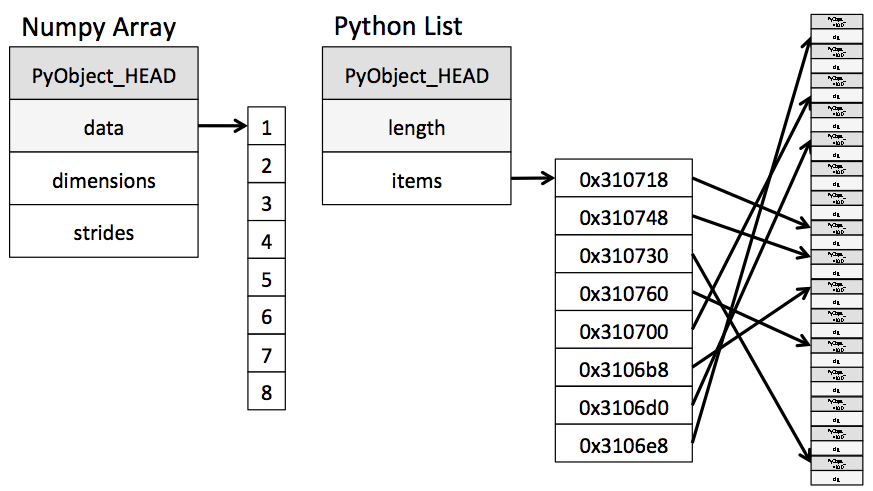
    
- Single pointer to one contiguous block of data.
- Python list uses a pointer to a block of pointers that point to the full Python object.
- It's a trade off of efficiciency of storage and manipulation vs flexibility

# Creating Arrays from Python Lists

`np.array` can be used to create arrays from Python Lists

In [1]:
import numpy as np

In [17]:
np.array([1, 4, 2, 5, 3, 7, 8])

array([1, 4, 2, 5, 3, 7, 8])

__N.B__ Unlike Python lists, Numpy arrays must contain the same type.

If they don't, Numpy will upcast, if possible.

In [18]:
np.array([3.14, 1, 2, 3])

array([3.14, 1.  , 2.  , 3.  ])

Unlike Python arrays, NumPy arrays can be multi-dimensional.

# Creating Arrays from Scratch

More efficient to use inbuilt routines from NumPy rather than programmatically e.g `for` loops

In [20]:
np.zeros(10, dtype=int)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [21]:
# Create a 3x5 floating-point array filled with ones
np.ones((3, 5), dtype=float)

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

In [22]:
# Create a 3x5 array filled with 3.14
np.full((3, 5), 3.14)

array([[3.14, 3.14, 3.14, 3.14, 3.14],
       [3.14, 3.14, 3.14, 3.14, 3.14],
       [3.14, 3.14, 3.14, 3.14, 3.14]])

In [24]:
# Create an array filled with a linear sequence
# Starting at 0, ending at 20, stepping by 3
# (this is similar to the built-in range() function)
np.arange(0, 20, 3)

array([ 0,  3,  6,  9, 12, 15, 18])

In [25]:
# Create an array of five values evenly spaced between 0 and 1
np.linspace(0, 1, 5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [31]:
# Create a 3x3 array of uniformly distributed random values between 0 and 1
np.random.random((3, 3))

array([[0.79066934, 0.2714416 , 0.28093163],
       [0.27100178, 0.62424161, 0.46122487],
       [0.57359   , 0.29017115, 0.48948991]])

In [45]:
# Create a 3x3 array of random integers in the interval [0, 10)
np.random.randint(0, 10, (3, 3))

array([[5, 4, 9],
       [6, 9, 4],
       [7, 4, 9]])

# The Basics of NumPy Arrays

We're going to look at several examples of how to use NumPy arrays manipulation for the following tasks:

- Access data and subarrays
- Split data
- Reshape data
- Join arrays.

- Warning: this is super dry! As with most dull things in life, it forms the basis for more exciting things later in the workshop.

# NumPy Array Attributes

Goal: define three random arrays; 1-dimensional, 2-dimensional and 3-dimensional

In [2]:
np.random.seed(0)  # seed for reproducibility

x1 = np.random.randint(10, size=6)  # One-dimensional array
x2 = np.random.randint(10, size=(3, 4))  # Two-dimensional array
x3 = np.random.randint(10, size=(3, 4, 5))  # Three-dimensional array

In [4]:
print (x2)

[[3 5 2 4]
 [7 6 8 8]
 [1 6 7 7]]


Arrays have the following attributes:
- `ndim` (number of dimensions)
- `shape`(size of each dimension)
- `size`(total size of the array)
- `dtype` (data type of the array)

In [54]:

print(x3)

[[[8 1 5 9 8]
  [9 4 3 0 3]
  [5 0 2 3 8]
  [1 3 3 3 7]]

 [[0 1 9 9 0]
  [4 7 3 2 7]
  [2 0 0 4 5]
  [5 6 8 4 1]]

 [[4 9 8 1 1]
  [7 9 9 3 6]
  [7 2 0 3 5]
  [9 4 4 6 4]]]


In [10]:
np.random.seed(0)  # seed for reproducibility

x1 = np.random.randint(10, size=6)  # One-dimensional array
x2 = np.random.randint(10, size=(3, 4))  # Two-dimensional array
x3 = np.random.randint(10, size=(3, 4, 5))  # Three-dimensional array
print(x2.size)

12


Question: how many dimensions does x2 have?

What is the size of x2?

# Array indexing: Accessing Single Elements

- Quite familiar to the way you access an element of a list

In [57]:
x1

array([5, 0, 3, 3, 7, 9])

In [58]:
x1[0]

5

In [60]:
x1[4]

7

To access from the __end__ of an array, use negative indexing:

In [61]:
x1[-1]

9

In [64]:
x1[-2]

7

For multi-dimensional arrays, items can be accessed using a comma-separated tuple of indices:

In [66]:
x2

array([[3, 5, 2, 4],
       [7, 6, 8, 8],
       [1, 6, 7, 7]])

In [67]:
x2[0, 0]

3

In [69]:
x2[2, -1]

7

How to access the number 1?

In [11]:
number_one = x2[2, 0]
number_one

1

Values can be modified using any of the above index notation:

In [70]:
x2[0, 0] = 12
x2

array([[12,  5,  2,  4],
       [ 7,  6,  8,  8],
       [ 1,  6,  7,  7]])

# Array Slicing: Accessing Subarrays

- Square brackets can be used to access individual elements at a given index.
- Using the colon (`:`) known as the slice notation, you can access subarrays as follows:

`x[start:stop:step]`

- If any left undefined `start=0`, `stop=size of dimension` and `step=1`

In [71]:
# for one dimensional arrays
x = np.arange(10)
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [72]:
x[:5]  # first five elements

array([0, 1, 2, 3, 4])

In [74]:
x[5:]  # elements after index 5

array([5, 6, 7, 8, 9])

In [75]:
x[4:7]  # middle sub-array

array([4, 5, 6])

In [76]:
x[::2]  # every other element

array([0, 2, 4, 6, 8])

In [77]:
x[1::2]  # every other element, starting at index 1

array([1, 3, 5, 7, 9])

Step can be negative, which reverses an array

In [78]:
x[::-1]  # all elements, reversed

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

In [79]:
x[5::-2]  # reversed every other from index 5

array([5, 3, 1])

## Multi-dimensional arrays

In [80]:
x2

array([[12,  5,  2,  4],
       [ 7,  6,  8,  8],
       [ 1,  6,  7,  7]])

In [81]:
x2[:2, :3]  # two rows, three columns

array([[12,  5,  2],
       [ 7,  6,  8]])

In [82]:
x2[:3, ::2]  # all rows, every other column

array([[12,  2],
       [ 7,  8],
       [ 1,  7]])

In [83]:
# reversing subarray dimensions
x2[::-1, ::-1]

array([[ 7,  7,  6,  1],
       [ 8,  8,  6,  7],
       [ 4,  2,  5, 12]])

## How to access a single row or column?

In [84]:
print(x2[:, 0])  # first column of x2

[12  7  1]


In [85]:
print(x2[0, :])  # first row of x2

[12  5  2  4]


In [88]:
print(x2[1])  # equivalent to x2[0, :]

[7 6 8 8]


## Subarrays as no-copy views

In [89]:
print(x2)

[[12  5  2  4]
 [ 7  6  8  8]
 [ 1  6  7  7]]


In [90]:
# extract a 2 x 2 subarray from x2
x2_sub = x2[:2, :2]
x2_sub

array([[12,  5],
       [ 7,  6]])

In [91]:
# lets modify x2_sub
x2_sub[0, 0] = 99
x2_sub

array([[99,  5],
       [ 7,  6]])

In [92]:
# But, let's see what's happened to x2...
x2

array([[99,  5,  2,  4],
       [ 7,  6,  8,  8],
       [ 1,  6,  7,  7]])

This is sort of useful - we can process bits of a large dataset without needing to copy buffer data

## Creating copies of arrays

In [93]:
x2_sub_copy = x2[:2, :2].copy()
print(x2_sub_copy)

[[99  5]
 [ 7  6]]


In [96]:
# if we modify the subarray now, the original is untouched!
x2_sub_copy[0, 0] = 42
print(x2_sub_copy)

[[42  5]
 [ 7  6]]


In [97]:
x2

array([[99,  5,  2,  4],
       [ 7,  6,  8,  8],
       [ 1,  6,  7,  7]])

## Reshaping of Arrays

Use the `reshape`method

In [13]:
# Put numbers 1 to 9 in a 3 x 3 grid
# N.B Size of original array __must__ match that of the reshaped array
grid = np.arange(1, 10).reshape((3, 3))
print(grid)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [101]:
# Another use case is reshaping an 1D array to 2D row or column matrix
x = np.array([1, 2, 3])

# row vector via reshape
x.reshape((1, 3))

array([[1, 2, 3]])

In [103]:
# column vector via reshape
x.reshape((3, 1))

array([[1],
       [2],
       [3]])

In [14]:
grid.reshape(9,1)

array([[1],
       [2],
       [3],
       [4],
       [5],
       [6],
       [7],
       [8],
       [9]])

## Array Concatenation

- Concatenation, or joining of two arrays in NumPy, is primarily accomplished using the routines
    - `np.concatenate`
    - `np.vstack`
    - `np.hstack` 
     
- `np.concatenate` takes a tuple or list of arrays as its first argument:

In [104]:
x = np.array([1, 2, 3])
y = np.array([3, 2, 1])
np.concatenate([x, y])

array([1, 2, 3, 3, 2, 1])

In [105]:
# Concatenate more than two arrays:
z = [99, 99, 99]
print(np.concatenate([x, y, z]))

[ 1  2  3  3  2  1 99 99 99]


In [ ]:
# Concatentate 2D arrays:
grid = np.array([[1, 2, 3],
                 [4, 5, 6]])

In [106]:
# concatenate along the first axis
np.concatenate([grid, grid])

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9],
       [1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [107]:
# concatenate along the second axis (zero-indexed)
np.concatenate([grid, grid], axis=1)

array([[1, 2, 3, 1, 2, 3],
       [4, 5, 6, 4, 5, 6],
       [7, 8, 9, 7, 8, 9]])

## Working with arrays of mixed dimensions?

- Possibly easier to use a vertical stack (`np.vstack`) than horizontal stacking (`np.hstack`)

In [15]:
x = np.array([1, 2, 3])
grid = np.array([[9, 8, 7],
                 [6, 5, 4]])

# vertically stack the arrays
np.vstack([x, grid])

array([[1, 2, 3],
       [9, 8, 7],
       [6, 5, 4]])

In [16]:
# horizontally stack the arrays
y = np.array([[99],
              [99]])
np.hstack([grid, y])

array([[ 9,  8,  7, 99],
       [ 6,  5,  4, 99]])

N.B `np.dstack` will stack arrays along the third axis.

# Exploring NumPy's UFuncs

- Help speed up computation significantly

- Useful for array arithmetic, applying operations to all values.

- Also useful for aggregate functions

## Array arithmetic

Feel quite natural as they all use standard arithmetic:

In [ ]:
x = np.arange(4)
print("x     =", x)
print("x + 5 =", x + 5)
print("x - 5 =", x - 5)
print("x * 2 =", x * 2)
print("x / 2 =", x / 2)
print("x // 2 =", x // 2)  # floor division

In [ ]:
print("-x     = ", -x) #negation
print("x ** 2 = ", x ** 2) # 

In [ ]:
# Operators can also be combined
-(0.5*x + 1) ** 2

Each of the previous operation are *wrappers* for specific NumPy functions:

- e.g `+` is the wrapper for the `add` function. 

In [ ]:
np.add(x, 2)

## Absolute value

NumPy also interacts with other inbuilt Python arithmetic operators: 

- e.g Python's built-in absolute value function

In [ ]:
x = np.array([-2, -1, 0, 1, 2])
abs(x)

In [19]:
# N.B if you're stuck with this stuff don't forget the inbuilt help ? after a function.
abs?

# Aggregations: Min, Max, and Everything In Between

When faced with large amounts of data, summary statistics are useful to first calculate:

## Summing the Values in an Array

Consider computing the sum of all values in an array. *Python* itself can do this using the built-in `sum` function

In [23]:
L = np.random.random(100)
sum(L)

51.66289966242654

## Multi dimensional aggregates

One common type of aggregation operation is an aggregate along a row or column e.g:

In [24]:
M = np.random.random((3, 4))
print(M)

[[0.15986708 0.14382937 0.64946303 0.5392236 ]
 [0.32568477 0.14701389 0.15987007 0.12941234]
 [0.57892239 0.09226017 0.91054472 0.08297175]]


In [25]:
# By default, each NumPy aggregation function will return aggregate over entire array
M.sum()

3.91906316880573

Aggregation functions take an additional argument specifying the axis along which the aggregate is computed. 

For example, we can find the minimum value within each column by specifying `axis=0`:

In [26]:
M

array([[0.15986708, 0.14382937, 0.64946303, 0.5392236 ],
       [0.32568477, 0.14701389, 0.15987007, 0.12941234],
       [0.57892239, 0.09226017, 0.91054472, 0.08297175]])

In [27]:
M.min(axis=0)

array([0.15986708, 0.09226017, 0.15987007, 0.08297175])

In [28]:
M.max(axis=1)

array([0.64946303, 0.32568477, 0.91054472])